In [1]:
import os
import sys

# add the directory containing the notebook to Python path
sys.path.append(os.getcwd())

import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

Homework #5 - Problem 5: Interconnect sizing

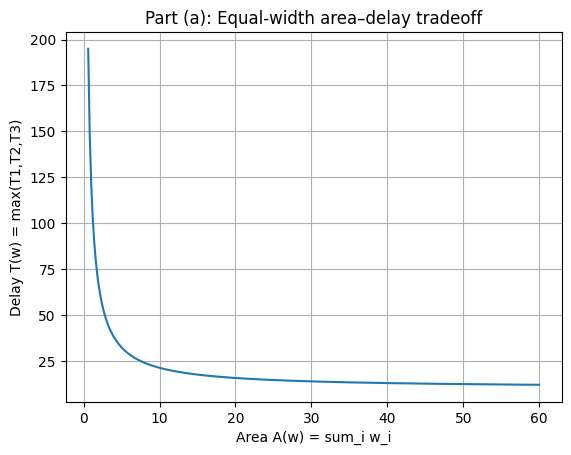

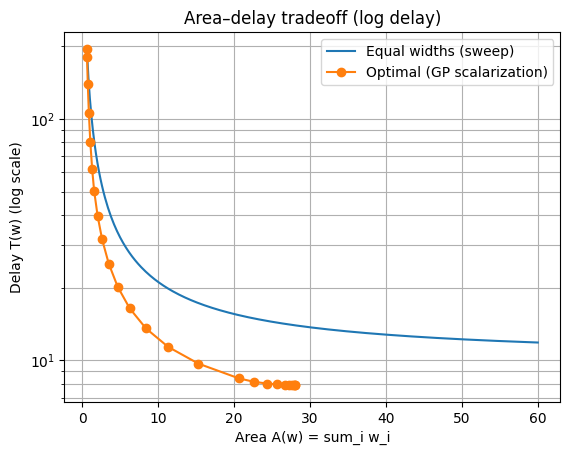

mu, area, delay, w
1.000e-03, 0.6000, 195.0000, [0.1 0.1 0.1 0.1 0.1 0.1]
1.778e-03, 0.6235, 179.5758, [0.1193 0.1    0.1    0.1042 0.1    0.1   ]
3.162e-03, 0.7217, 138.8918, [0.1597 0.1    0.1    0.1389 0.1    0.1231]
5.623e-03, 0.8624, 105.5257, [0.2141 0.1    0.1    0.1853 0.1    0.1631]
1.000e-02, 1.0501, 80.4954, [0.2875 0.1    0.1    0.2471 0.1    0.2156]


In [4]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

# intialize parameters
Wmin = 0.1
Wmax = 10.0

Cload1 = 1.5
Cload2 = 1.0
Cload3 = 5.0

def delays_numpy(w):
    # w: shape (6,)
    w = np.asarray(w, dtype=float)
    C = w.copy()         # Ci = wi
    R = 1.0 / w          # Ri = 1/wi

    C1, C2, C3, C4, C5, C6 = C
    R1, R2, R3, R4, R5, R6 = R

    T1 = (C3 + Cload1) * (R1 + R2 + R3) \
         + C2 * (R1 + R2) \
         + (C1 + C4 + C5 + C6 + Cload2 + Cload3) * R1

    T2 = (C5 + Cload2) * (R1 + R4 + R5) \
         + (C4 + C6 + Cload3) * (R1 + R4) \
         + (C1 + C2 + C3 + Cload1) * R1

    T3 = (C6 + Cload3) * (R1 + R4 + R6) \
         + (C4 + C5 + Cload2) * (R1 + R4) \
         + (C1 + C2 + C3 + Cload1) * R1

    return T1, T2, T3

def max_delay_numpy(w):
    T1, T2, T3 = delays_numpy(w)
    return max(T1, T2, T3)

#(a): Equal widths sweep
w_grid = np.linspace(Wmin, Wmax, 300)
A_equal = []
T_equal = []

for s in w_grid:
    w = np.array([s]*6)
    A_equal.append(np.sum(w))
    T_equal.append(max_delay_numpy(w))

A_equal = np.array(A_equal)
T_equal = np.array(T_equal)

#(b): GP scalarization sweep
mus = np.logspace(-3, 3, 25) 
A_opt = []
T_opt = []
W_opt = []

for mu in mus:
    w = cp.Variable(6, pos=True) 
    t = cp.Variable(pos=True)    

    
    C = w  # Ci = wi
    R = 1 / w # Ri = 1/wi

    C1, C2, C3, C4, C5, C6 = C[0], C[1], C[2], C[3], C[4], C[5]
    R1, R2, R3, R4, R5, R6 = R[0], R[1], R[2], R[3], R[4], R[5]

    T1 = (C3 + Cload1) * (R1 + R2 + R3) \
         + C2 * (R1 + R2) \
         + (C1 + C4 + C5 + C6 + Cload2 + Cload3) * R1

    T2 = (C5 + Cload2) * (R1 + R4 + R5) \
         + (C4 + C6 + Cload3) * (R1 + R4) \
         + (C1 + C2 + C3 + Cload1) * R1

    T3 = (C6 + Cload3) * (R1 + R4 + R6) \
         + (C4 + C5 + Cload2) * (R1 + R4) \
         + (C1 + C2 + C3 + Cload1) * R1

    A = cp.sum(w)  

    constraints = [
        w >= Wmin,
        w <= Wmax,
        T1 <= t,
        T2 <= t,
        T3 <= t,
    ]

    #GP scalarization objective
    obj = cp.Minimize(A + mu * t)
    prob = cp.Problem(obj, constraints)

    #Solve in GP mode
    prob.solve(gp=True) 

    if prob.status not in ("optimal", "optimal_inaccurate"):
        raise RuntimeError(f"GP solve failed for mu={mu}, status={prob.status}")

    w_val = np.array(w.value).reshape(-1)
    A_val = float(np.sum(w_val))
    T_val = float(max_delay_numpy(w_val))  

    W_opt.append(w_val)
    A_opt.append(A_val)
    T_opt.append(T_val)

A_opt = np.array(A_opt)
T_opt = np.array(T_opt)

#part a plots
plt.figure()
plt.plot(A_equal, T_equal)
plt.xlabel("Area A(w) = sum_i w_i")
plt.ylabel("Delay T(w) = max(T1,T2,T3)")
plt.title("Part (a): Equal-width area–delay tradeoff")
plt.grid(True)
plt.show()

#part b plots (log scale for delay)
plt.figure()
plt.plot(A_equal, T_equal, label="Equal widths (sweep)")
plt.plot(A_opt, T_opt, "o-", label="Optimal (GP scalarization)")
plt.yscale("log")
plt.xlabel("Area A(w) = sum_i w_i")
plt.ylabel("Delay T(w) (log scale)")
plt.title("Area–delay tradeoff (log delay)")
plt.grid(True, which="both")
plt.legend()
plt.show()

# Print some solutions recorded
print("mu, area, delay, w")
for mu, a, tval, wv in zip(mus[:5], A_opt[:5], T_opt[:5], W_opt[:5]):
    print(f"{mu:.3e}, {a:.4f}, {tval:.4f}, {np.round(wv, 4)}")
